In [1]:
import pandas as pd
from data_drift_module import DataDriftDetector, DriftVisualizer
from data_drift_module.config import ConfigSelector


In [ ]:

# ========== 第一步：載入您的資料 ==========
# 請修改以下路徑為您的實際資料路徑

# 檔案載入
reference_data = pd.read_csv(f'{proj_path}/data/training_data.csv')                     # 訓練資料或基準資料
drift_data = pd.read_csv(f'{proj_path}/data/production_data_with_drift.csv')            # 當前生產資料

print(f"  資料載入完成")
print(f"  參考資料: {reference_data.shape}")
print(f"  偏移資料: {drift_data.shape}")
print()


  資料載入完成
  參考資料: (2000, 14)
  偏移資料: (1000, 14)



In [5]:
# ========== 第二步：資料預處理（選擇性） ==========

# 1. 移除不需要檢查的欄位
columns_to_exclude = ['id', 'timestamp', 'user_id']  # 修改為您要排除的欄位
reference_data = reference_data.drop(columns = columns_to_exclude, errors = 'ignore')
drift_data = drift_data.drop(columns = columns_to_exclude, errors = 'ignore')

# 2. 確保兩個資料集有相同的欄位
common_columns = list(set(reference_data.columns) & set(drift_data.columns))
reference_data = reference_data[common_columns]
drift_data = drift_data[common_columns]

print(f"  預處理完成，共 {len(common_columns)} 個特徵將被檢查")
print()

  預處理完成，共 14 個特徵將被檢查



In [6]:

# ========== 第三步：執行漂移偵測 ==========

# 創建偵測器
detector = DataDriftDetector(
    reference_data = reference_data,
    threshold = 0.05  # 可調整: 0.01(嚴格) / 0.05(標準) / 0.10(寬鬆)
)

print("  開始執行漂移偵測...")
results_drift_data = detector.detect_drift(drift_data)
print()


  開始執行漂移偵測...



In [7]:

# ========== 第四步：查看結果 ==========
# results_drift_data
print("=" * 60)
print("📊 漂移偵測結果摘要")
print("=" * 60)
print(f"總特徵數: {results_drift_data['summary']['total_features']}")
print(f"發生漂移的特徵數: {results_drift_data['summary']['drifted_features']}")
print(f"漂移比例: {results_drift_data['summary']['drift_percentage']:.2f}%")
print()

# 列出發生漂移的特徵
drifted_features = detector.get_drifted_features()
if drifted_features:
    print("⚠️  發生漂移的特徵:")
    for feature in drifted_features:
        result = results_drift_data['feature_results'][feature]
        psi_value = result['tests']['psi']['value']
        print(f"  - {feature} (PSI: {psi_value:.4f})")
    print()
else:
    print("✓ 所有特徵均無顯著漂移")
    print()

📊 漂移偵測結果摘要
總特徵數: 14
發生漂移的特徵數: 9
漂移比例: 64.29%

⚠️  發生漂移的特徵:
  - num_late_payments (PSI: 0.4772)
  - data_date (PSI: 3.3599)
  - loan_amount (PSI: 0.3230)
  - marital_status (PSI: 0.1430)
  - employment_length_years (PSI: 0.1769)
  - credit_score (PSI: 0.1271)
  - annual_income (PSI: 0.3386)
  - age (PSI: 0.2691)
  - debt_to_income_ratio (PSI: 0.0223)



In [8]:
# ========== 第五步：詳細分析（選擇性） ==========
# results_drift_data
# 分析前 3 個發生漂移的特徵
if drifted_features:
    print("=" * 60)
    print("📈 前 3 個漂移特徵的詳細分析")
    print("=" * 60)
    print()
    
    for feature in drifted_features[:3]:
        result = results_drift_data['feature_results'][feature]
        print(f"特徵: {feature}")
        print(f"  類型: {result['feature_type']}")
        
        if result['feature_type'] == 'numerical':
            # 數值型特徵
            ks = result['tests']['ks_test']
            psi = result['tests']['psi']
            ref_stats = result['statistics']['reference']
            curr_stats = result['statistics']['current']
            
            print(f"  KS 檢定 p-value: {ks['p_value']:.4f}")
            print(f"  PSI 值: {psi['value']:.4f} - {psi['interpretation']}")
            print(f"  平均值: {ref_stats['mean']:.2f} → {curr_stats['mean']:.2f}")
            print(f"  標準差: {ref_stats['std']:.2f} → {curr_stats['std']:.2f}")
        else:
            # 類別型特徵
            chi2 = result['tests']['chi_square_test']
            psi = result['tests']['psi']
            
            print(f"  Chi-Square p-value: {chi2['p_value']:.4f}")
            print(f"  PSI 值: {psi['value']:.4f} - {psi['interpretation']}")
        
        print()

📈 前 3 個漂移特徵的詳細分析

特徵: num_late_payments
  類型: numerical
  KS 檢定 p-value: 0.0000
  PSI 值: 0.4772 - 顯著漂移 (Significant drift)
  平均值: 1.02 → 1.99
  標準差: 0.99 → 1.44

特徵: data_date
  類型: categorical
  Chi-Square p-value: 1.0000
  PSI 值: 3.3599 - 顯著漂移 (Significant drift)

特徵: loan_amount
  類型: numerical
  KS 檢定 p-value: 0.0000
  PSI 值: 0.3230 - 顯著漂移 (Significant drift)
  平均值: 149840.50 → 181661.75
  標準差: 51476.88 → 56741.60



In [9]:
# ========== 第六步：生成報告 ==========
# 需要注意, 這邊是用上面最後一個第五步
# 生成文字報告
text_report = detector.generate_report(output_format='text')
with open(f'{proj_path}/output/my_drift_report.txt', 'w', encoding='utf-8') as f:
    f.write(text_report)
print(f"文字報告已儲存: {proj_path}/output/my_drift_report.txt")

# 生成 Markdown 報告
md_report = detector.generate_report(output_format='markdown')
with open(f'{proj_path}/output/my_drift_report.md', 'w', encoding='utf-8') as f:
    f.write(md_report)
print(f"Markdown 報告已儲存: {proj_path}/output/my_drift_report.md")
print()


文字報告已儲存: /Users/curtis/GitHub/mlops/output/my_drift_report.txt
Markdown 報告已儲存: /Users/curtis/GitHub/mlops/output/my_drift_report.md



生成視覺化圖表...
圖表已儲存至: /Users/curtis/GitHub/mlops/output/drift_data_drift_summary.png


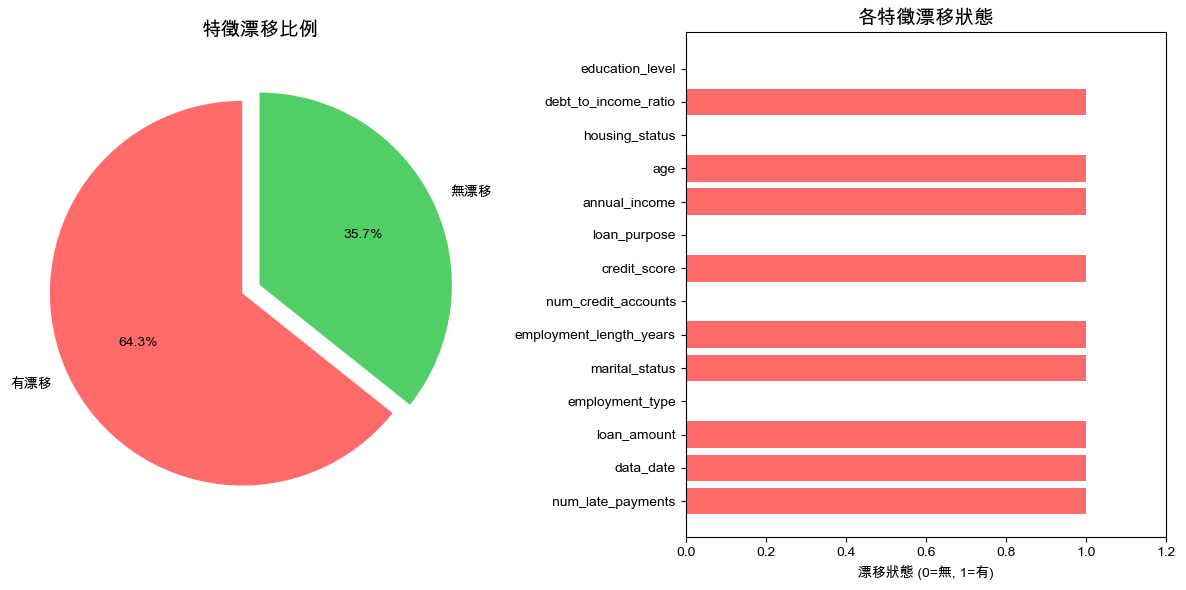

圖表已儲存至: /Users/curtis/GitHub/mlops/output/drift_data_psi_heatmap.png


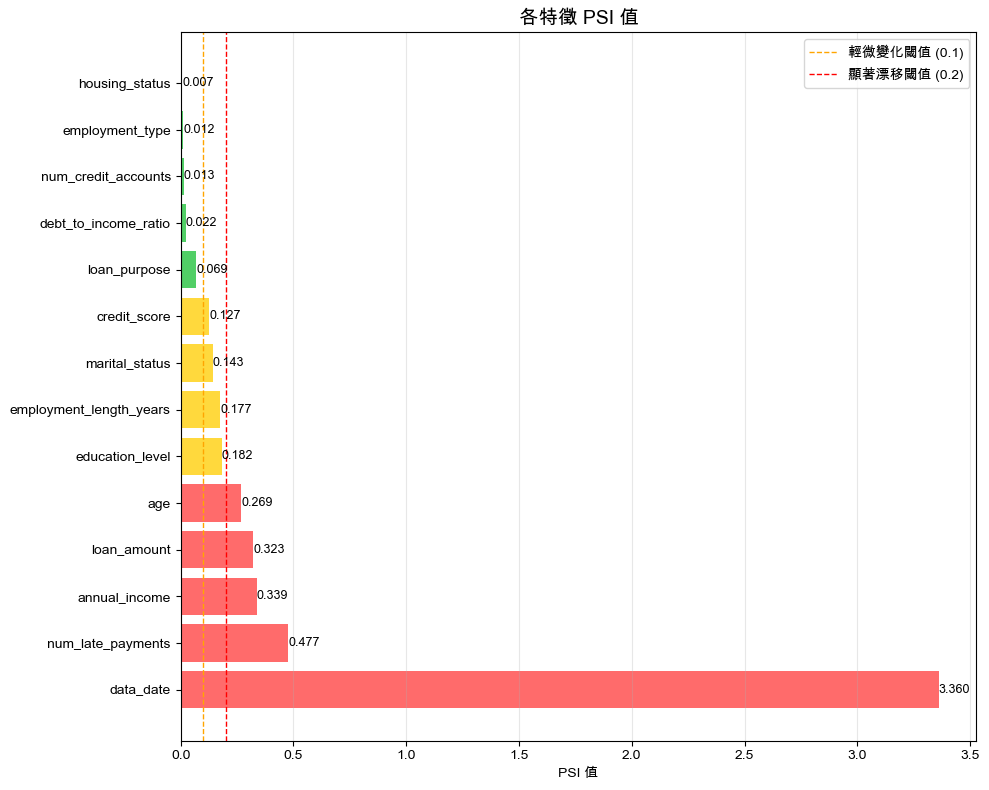

視覺化圖表已生成



In [11]:

# ========== 第七步：視覺化（選擇性） ==========

try:
    print("生成視覺化圖表...")
    visualizer = DriftVisualizer(detector)
    
    # 1. 繪製摘要圖
    visualizer.plot_drift_summary(save_path = f'{proj_path}/output/drift_data_drift_summary.png')
    
    # 2. 繪製 PSI 熱圖
    visualizer.plot_psi_heatmap(save_path = f'{proj_path}/output/drift_data_psi_heatmap.png')
    
    # 3. 繪製前 2 個漂移特徵的詳細圖
    # for i, feature in enumerate(drifted_features[:2]):
    #     result = results['feature_results'][feature]
    #     if result['feature_type'] == 'numerical':
    #         visualizer.plot_numerical_drift(feature, save_path = f'{proj_path}/output/drift_data_{feature}_drift.png')
    #     else:
    #         visualizer.plot_categorical_drift(feature, save_path = f'{proj_path}/output/drift_data_{feature}_drift.png')

    print("視覺化圖表已生成")
    
except ImportError:
    print("⚠️  視覺化功能需要安裝 matplotlib 和 seaborn")
    print("   執行: pip install matplotlib seaborn")

print()
